In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import ipywidgets as widgets
import json
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.lines as mlines
import csv
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# Leggi il file CSV con i risultati f0
base_dir = "dati_processati"
csv_file = os.path.join(base_dir, "f0_results_all.csv")

f0_results = {}

with open(csv_file, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        note_num = row['Note']
        f0_results[note_num] = {
            'first_peak': float(row['First Peak']) if row['First Peak'] != 'None' else None,
            'gcd': float(row['GCD']) if row['GCD'] != 'None' else None,
            'linear_reg': float(row['Linear Reg']) if row['Linear Reg'] != 'None' else None,
            'bayesian_map': float(row['Bayesian MAP']) if row['Bayesian MAP'] != 'None' else None,
        }

print(f"Caricati {len(f0_results)} risultati da {csv_file}")

Caricati 280 risultati da dati_processati/f0_results_all.csv


In [4]:
def estrai_armoniche_reali(f0, peak_freqs, peak_mags, num_armoniche=5, tolleranza=0.05):
    """
    Data una fondamentale f0, cerca tra i peak_freqs le armoniche corrispondenti.
    Restituisce due liste: le frequenze e le magnitudini delle armoniche trovate.
    Se un'armonica manca, inserisce None.
    """
    if f0 is None:
        return [None] * num_armoniche, [None] * num_armoniche
        
    armoniche_freqs = []
    armoniche_mags = []
    
    for n in range(1, num_armoniche + 1):
        freq_teorica = f0 * n
        
        distanze = np.abs(peak_freqs - freq_teorica)
        if distanze.size == 0:
            armoniche_freqs.append(None)
            armoniche_mags.append(None)
            continue
        idx_vicino = np.argmin(distanze)
        
        errore_relativo = distanze[idx_vicino] / freq_teorica
        
        if errore_relativo < tolleranza:
            armoniche_freqs.append(float(peak_freqs[idx_vicino]))
            armoniche_mags.append(float(peak_mags[idx_vicino]))
        else:
            armoniche_freqs.append(None)
            armoniche_mags.append(None)
            
    return armoniche_freqs, armoniche_mags


# Carica i picchi dal file JSON (dati_processati/spettri_peaks.json)
peaks_file = os.path.join(base_dir, "spettri_peaks.json")
with open(peaks_file, 'r') as f:
    peaks_dict = json.load(f)

armoniche_results = {}
NUM_ARMONICHE = 5

for sample, data in peaks_dict.items():
    freqs = np.array(data.get("peaks", {}).get('frequencies', []))
    mags = np.array(data.get("peaks", {}).get('magnitudes', []))

    # Mappatura sample -> chiave CSV: prova corrispondenze dirette o estrai numeri (es. Nota_1 -> 1)
    sample_key = sample
    if sample_key not in f0_results:
        m = re.search(r"(\d+)", sample)
        if m:
            sample_key = m.group(1)

    f0_corrente = f0_results.get(sample_key, {}).get('bayesian_map')

    arm_freqs, arm_mags = estrai_armoniche_reali(f0_corrente, freqs, mags, num_armoniche=NUM_ARMONICHE)

    armoniche_results[sample] = {
        'f0': f0_corrente,
        'frequenze': arm_freqs,
        'magnitudini': arm_mags
    }

print("Finito! Tutte le armoniche sono state salvate.")
# stampa le armoniche per verifica
for sample, res in armoniche_results.items():
    print(f"Sample: {sample}")
    print(f"  f0: {res['f0']}")
    for i, (freq, mag) in enumerate(zip(res['frequenze'], res['magnitudini']), start=1):
        print(f"  Armonica {i}: Frequenza = {freq}, Magnitudine = {mag}")


Finito! Tutte le armoniche sono state salvate.
Sample: Nota_1
  f0: 1563.2614400096113
  Armonica 1: Frequenza = 1562.6370790865697, Magnitudine = 13227799.3103737
  Armonica 2: Frequenza = 3127.338407947362, Magnitudine = 345313611.5577157
  Armonica 3: Frequenza = 4689.975487033932, Magnitudine = 36740815.48493656
  Armonica 4: Frequenza = 6252.6125661205015, Magnitudine = 905218.8154263395
  Armonica 5: Frequenza = 7817.313894981294, Magnitudine = 2686.190034813011
Sample: Nota_2
  f0: 1481.8909221056742
  Armonica 1: Frequenza = 1481.8912352831248, Magnitudine = 424604169.2650683
  Armonica 2: Frequenza = 2963.7824705662497, Magnitudine = 421751984.0192242
  Armonica 3: Frequenza = 4445.6737058493745, Magnitudine = 4545198.494496271
  Armonica 4: Frequenza = 5927.564941132499, Magnitudine = 7660864.047228043
  Armonica 5: Frequenza = 7409.456176415624, Magnitudine = 4136401.452820874
Sample: Nota_3
  f0: 330.6670939845324
  Armonica 1: Frequenza = 329.8213467704993, Magnitudine = 2

In [5]:
features = []
sample_names = []

for sample, results in armoniche_results.items():
    mags = results['magnitudini']
    
    fundamental_power = mags[0]

    if fundamental_power is None or fundamental_power <= 0:
        continue

    row_db = []
    for m in mags:
        if m is None or m <= 0:
            row_db.append(-50.0)
        else:
            val_db = 10 * np.log10(m / fundamental_power)
            row_db.append(val_db)
            
    features.append(row_db)
    sample_names.append(sample)

data = np.array(features)

# Numero di registri prefissato
n_clusters = 5

kmeans = KMeans(n_clusters = n_clusters,
                init = "random",
                n_init = 10000,  
                copy_x = True,
                algorithm = "lloyd").fit(data)

print("Clustering completato!")


Clustering completato!


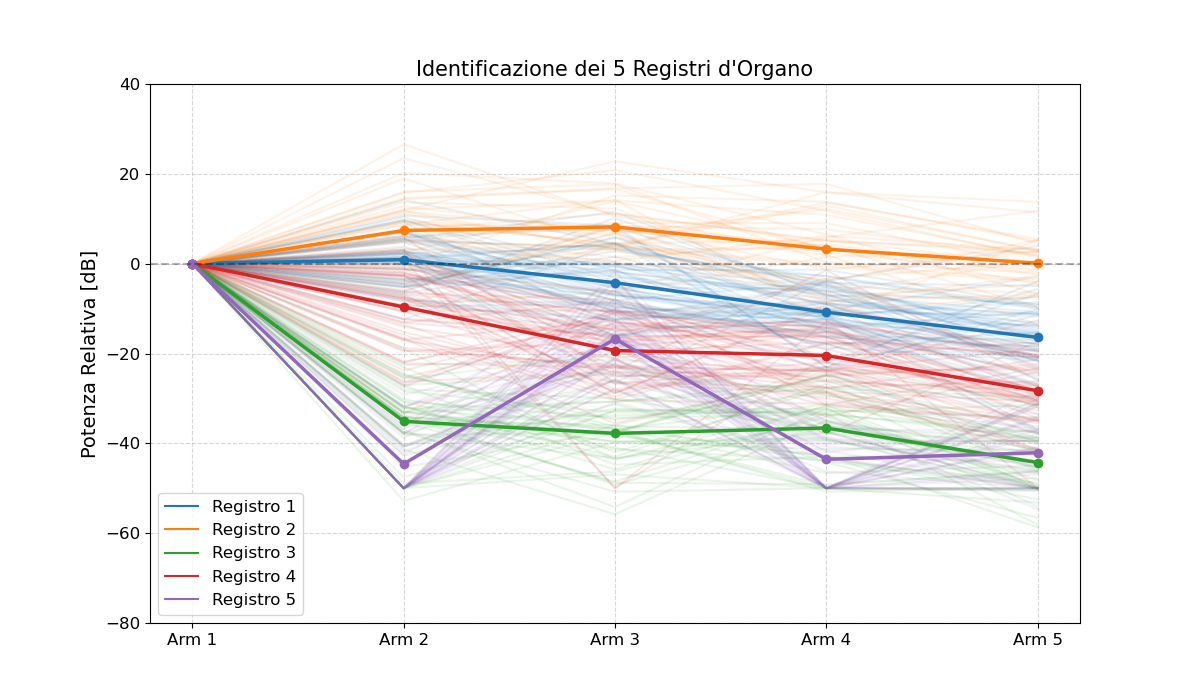

In [6]:
plt.rcParams.update({
    'font.size': 12,          # Dimensione base per tutto
    'axes.titlesize': 15,     # Titolo del grafico
    'axes.labelsize': 14,     # Etichette X e Y
    'xtick.labelsize': 12,    # Numeretti asse X
    'ytick.labelsize': 12,    # Numeretti asse Y
    'legend.fontsize': 12
})

# Prepariamo il DataFrame per il plot
columns = [f"Arm {i}" for i in range(1, 6)]
database = pd.DataFrame(data, columns=columns)
database["Cluster"] = kmeans.labels_

# Setup colori
cmap = plt.get_cmap("tab10")
manual_selection = {i: cmap(i) for i in range(5)}
handles = [mlines.Line2D([], [], color=manual_selection[i], label=f"Registro {i+1}") for i in range(5)]

# Plot
plt.figure(figsize=(12, 7))
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.1)

#linee delle medie dei cluster con punti e legenda
for i in range(n_clusters):
    cluster_data = database[database["Cluster"] == i][columns]
    mean_values = cluster_data.mean()
    plt.plot(columns, mean_values, color=manual_selection[i], linewidth=2.5, label=f"Media Registro {i+1}", marker='o')

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Linea della fondamentale
plt.ylabel("Potenza Relativa [dB]")
plt.title("Identificazione dei 5 Registri d'Organo")
plt.ylim(-80, 40) # Visualizziamo dai -80dB allo 0 (e un po' sopra per margine)
plt.legend(handles=handles)
plt.grid(linestyle="--", alpha=0.5)
plt.show()

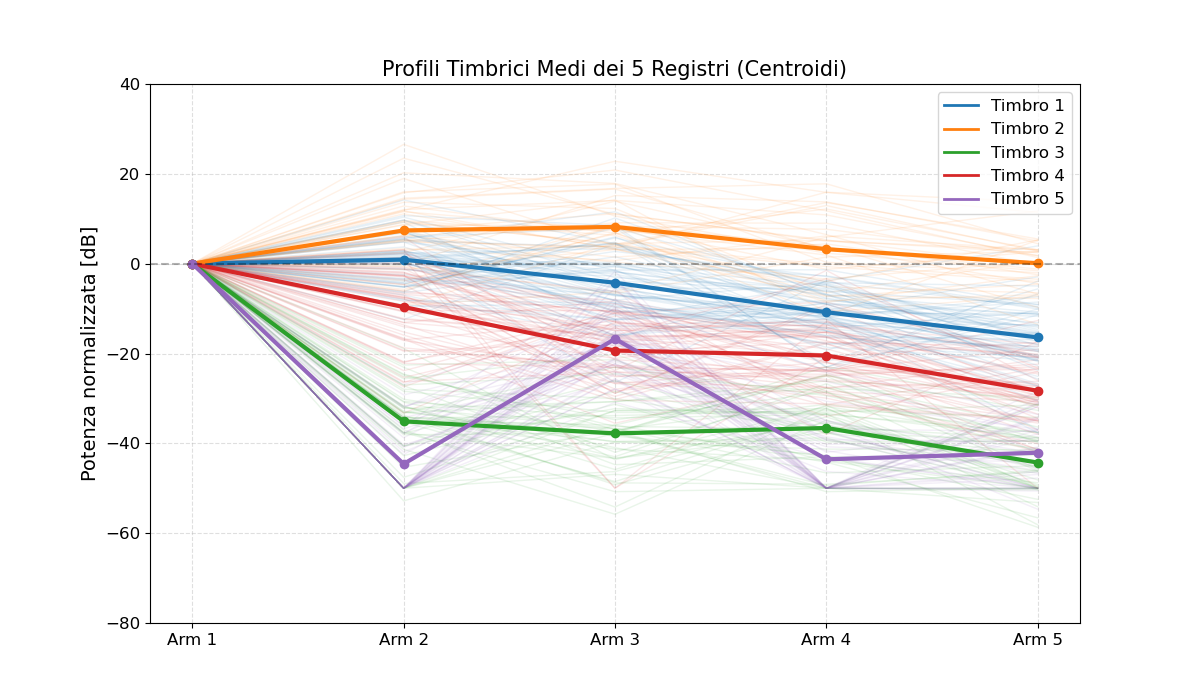

In [7]:
centroids = kmeans.cluster_centers_ 

# Creiamo un DataFrame per i centroidi usando le stesse 'columns' delle armoniche
db_centroids = pd.DataFrame(centroids, columns=columns)
db_centroids["Timbro_ID"] = [0, 1, 2, 3, 4] 

# 2. Setup della Legenda
handles = [
    mlines.Line2D([], [], color=manual_selection[i], label=f"Timbro {i+1}", linewidth=2)
    for i in range(5)
]

plt.figure(figsize=(12, 7))

# 3. Disegniamo lo sfondo: tutte le singole note (alpha molto basso)
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.1, linewidth=1)

for i, row in db_centroids.iterrows():
    plt.plot(columns, row[columns], 
             color=manual_selection[int(row["Timbro_ID"])], 
             linewidth=3, 
             marker='o', 
             markersize=6)

# 5. Formattazione finale
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.ylabel("Potenza normalizzata [dB]")
plt.title("Profili Timbrici Medi dei 5 Registri (Centroidi)")
plt.ylim(-80, 40) 
plt.margins(x=0.05)
plt.legend(handles=handles, loc='upper right')
plt.grid(linestyle="--", alpha=0.4)

plt.show()

plt.savefig(os.path.join(base_dir, "timbro_centroidi.png"))

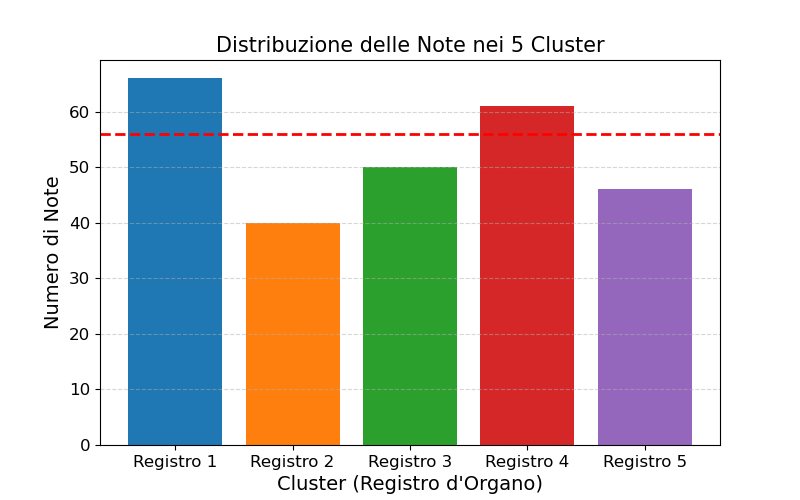

In [8]:
cluster_counts = database["Cluster"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index, cluster_counts.values, color=[manual_selection[i] for i in cluster_counts.index])  
plt.axhline(56, color="r", linestyle="--", linewidth=2) 
plt.xlabel("Cluster (Registro d'Organo)")
plt.ylabel("Numero di Note")
plt.title("Distribuzione delle Note nei 5 Cluster")
plt.xticks(cluster_counts.index, [f"Registro {i+1}" for i in cluster_counts.index])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


plt.savefig(os.path.join(base_dir, "timbro_centroidi_registri.png"))

In [9]:
number_of_iterations = 100
counters = np.zeros((number_of_iterations, 5), dtype=int)
for i in range(number_of_iterations):
    kmeans = KMeans(n_clusters = 5,
                    init = "random",
                    n_init = 1000, 
                    copy_x = True,
                    algorithm = "lloyd").fit(data)
    for cluster in range(5):
        counters[i][cluster] = np.sum(kmeans.labels_ == cluster)
average_bins = np.mean(counters, axis=0)

Il cluster 1 contiene in media 51.08 note
Il cluster 2 contiene in media 53.35 note
Il cluster 3 contiene in media 53.52 note
Il cluster 4 contiene in media 52.95 note
Il cluster 5 contiene in media 52.1 note


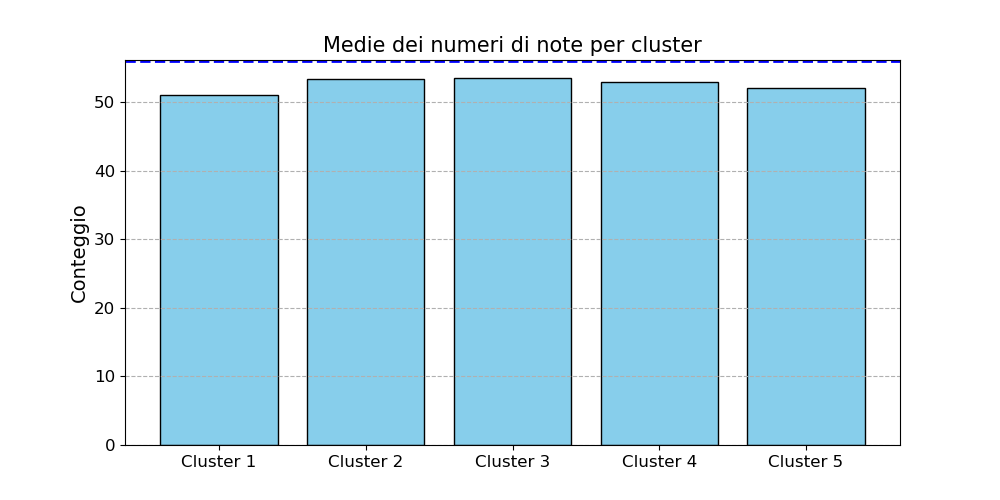

In [10]:
for i in range(5):
    print(f"Il cluster {i+1} contiene in media {average_bins[i]} note")

plt.figure(figsize=(10, 5))
plt.bar(range(5), average_bins, tick_label=[f"Cluster {i+1}" for i in range(5)], color="skyblue", edgecolor="black")
plt.axhline(56, color="blue", linestyle="--", linewidth=2)
plt.title("Medie dei numeri di note per cluster")
plt.ylabel("Conteggio")
plt.grid(axis="y", linestyle="--")
plt.show()

plt.savefig(os.path.join(base_dir, "cluster_counts.png"))

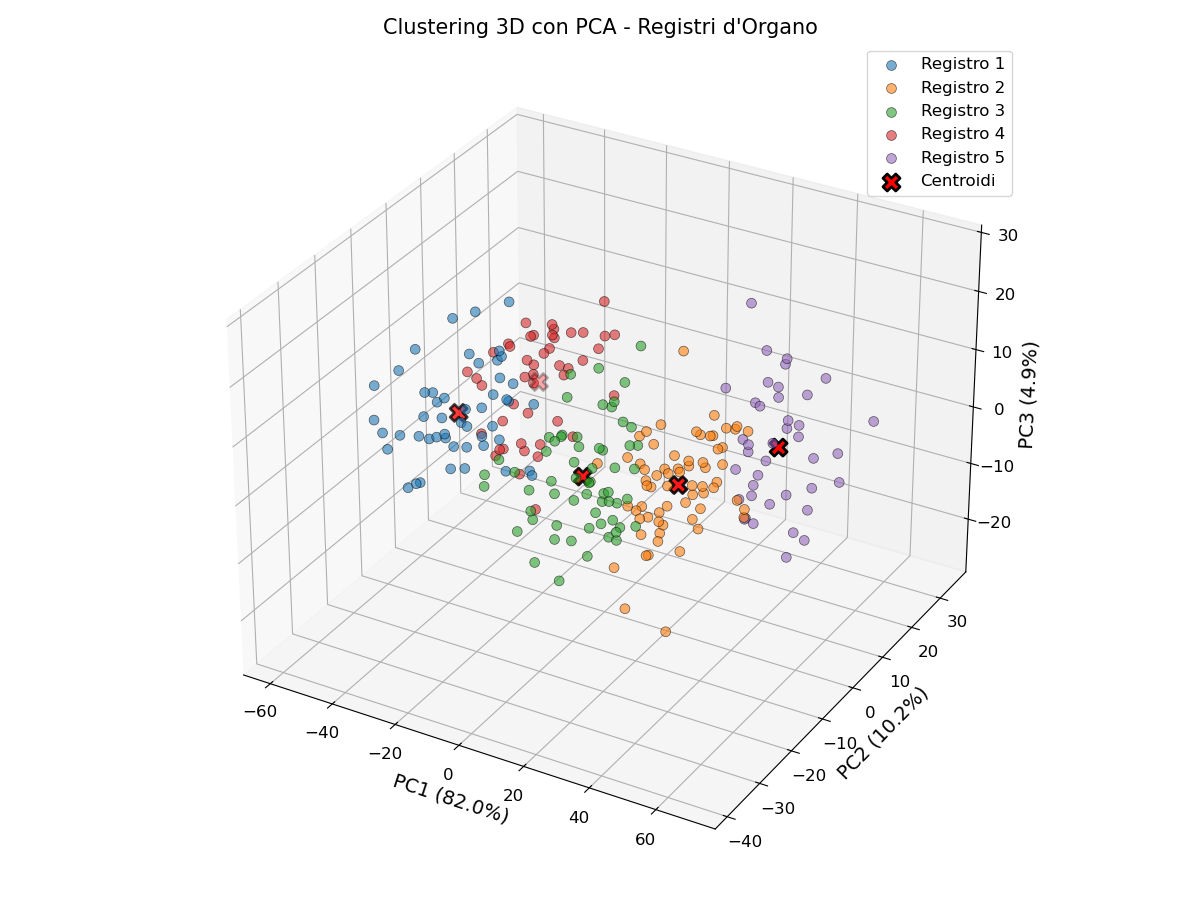

In [11]:
# Applica PCA per ridurre a 3 dimensioni
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data)

# Crea il grafico 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot dei campioni colorati per cluster
for cluster_id in range(n_clusters):
    mask = kmeans.labels_ == cluster_id
    ax.scatter(data_pca[mask, 0], data_pca[mask, 1], data_pca[mask, 2],
               c=[manual_selection[cluster_id]], label=f"Registro {cluster_id+1}",
               s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot dei centroidi PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], centroids_pca[:, 2],
           c='red', marker='X', s=150, edgecolors='black', linewidth=2,
           label='Centroidi')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax.set_title('Clustering 3D con PCA - Registri d\'Organo')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig(os.path.join(base_dir, "pca_clustering_3d.png"))
